In [1]:
import umap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as mcm
import matplotlib.colors as mcol
from scipy.optimize import curve_fit
from sklearn.preprocessing import StandardScaler
from matplotlib import ticker
#from matplotlib.gridspec import GridSpec
import scipy.stats as sts
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy.ma as nma

plt.style.use('./presentation.mplstyle')


In [2]:
sources = pd.read_csv('v1saga_dwarfs.csv')
print(sources.shape)

smorph = pd.read_csv('saga_morph.csv')
print(smorph.shape)

galex = pd.read_csv('v1GALEX_dwarfs.csv')
print(np.shape(galex))

(6337, 26)
(6211, 78)
(6337, 15)


In [12]:
bands = {'g':[mcm.Blues,'tab:blue'],'r':[mcm.Greens,'tab:green'],'i':[mcm.Oranges,'tab:orange'],'z':[mcm.Reds,'tab:red']}

npr = {'gini':[[0.4,0.6],r'$Gini$',r'${\it G}$'],'m20':[[-2,-1],r'$M_{20}$',r'$M_{20}$'],
       'c':[[2,3.5],r'$Concentration$',r'${\it C}$'],'a':[[-0.3,0.3],r'$Asymmetry$',r'${\it A}$'],'s':[[-0.1,0.1],r'$Smoothness$',r'${\it S}$'],
       'rpetro':[[8,38],r'$Petrosian\ R$',r'$R_p$'],'n':[[0.0,4.0],r'$Sersic\ n$',r'${\it n}$'],'rhalf':[[0,20],r'$Sersic\ R$',r'$R_{0.5}$']}

In [22]:
gprop = pd.DataFrame()
gprop['ind'],gprop['logM'],gprop['zspec']=sources['ind'],sources['logM'],sources['zspec']
gprop['log_ssfr'],gprop['flag_nondet']= galex['log_sfr']-gprop['logM'],galex['flag_nondet']
print(np.shape(gprop))

del sources,galex

smerge = smorph.merge(right=gprop,how='left', left_on='ind0', right_on='ind')
print(smerge.shape)


(6337, 5)
(6211, 83)


In [42]:
selc = smerge[(smerge['r20_psf_g']>0.5)&(smerge['snr_pix_g']>2.5)&(smerge['flag_g']<=1)&(smerge['snr_pix_r']>2.5)&(smerge['r20_psf_g']>0.5)&(smerge['flag_r']<=1)&(smerge['flag_nondet']==False)]
print(selc.shape)

penguin_data = selc[
    ['logM','zspec','log_ssfr','gini_g', 'm20_g','a_s_g', 'c_g','rpetro_g', 'n_g', 'rhalf_g',
    'gini_r', 'm20_r','a_s_r', 'c_r','rpetro_r', 'n_r', 'rhalf_r']].values

print(penguin_data.shape)
scaled_data = StandardScaler().fit_transform(penguin_data)

(2085, 83)
(2085, 17)


In [43]:
reducer = umap.UMAP(min_dist=0.4,n_neighbors=5)
embedding = reducer.fit_transform(scaled_data)
print(embedding.shape)

(2085, 2)


Text(0, 0.5, '$UMAP_2$')

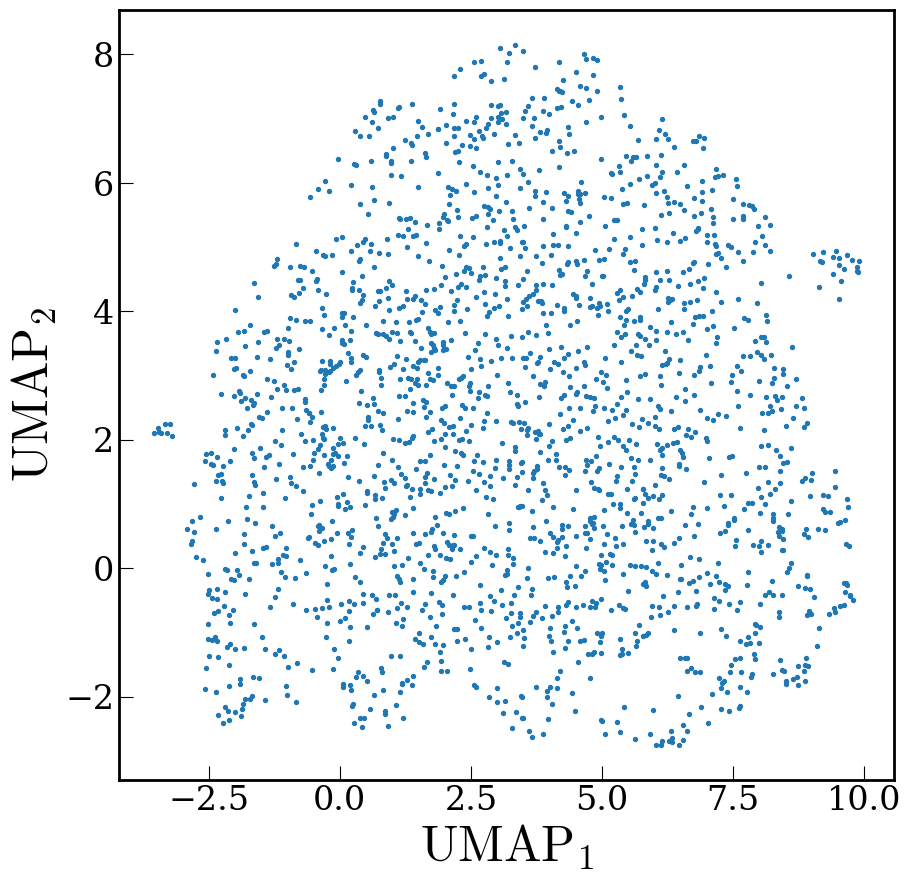

In [44]:
fig,ax=plt.subplots(figsize=(10,10))

ax.scatter(embedding[:,0],embedding[:,1],s=8)
ax.set_xlabel(r'$UMAP_1$',fontsize=36)
ax.set_ylabel(r'$UMAP_2$',fontsize=36)


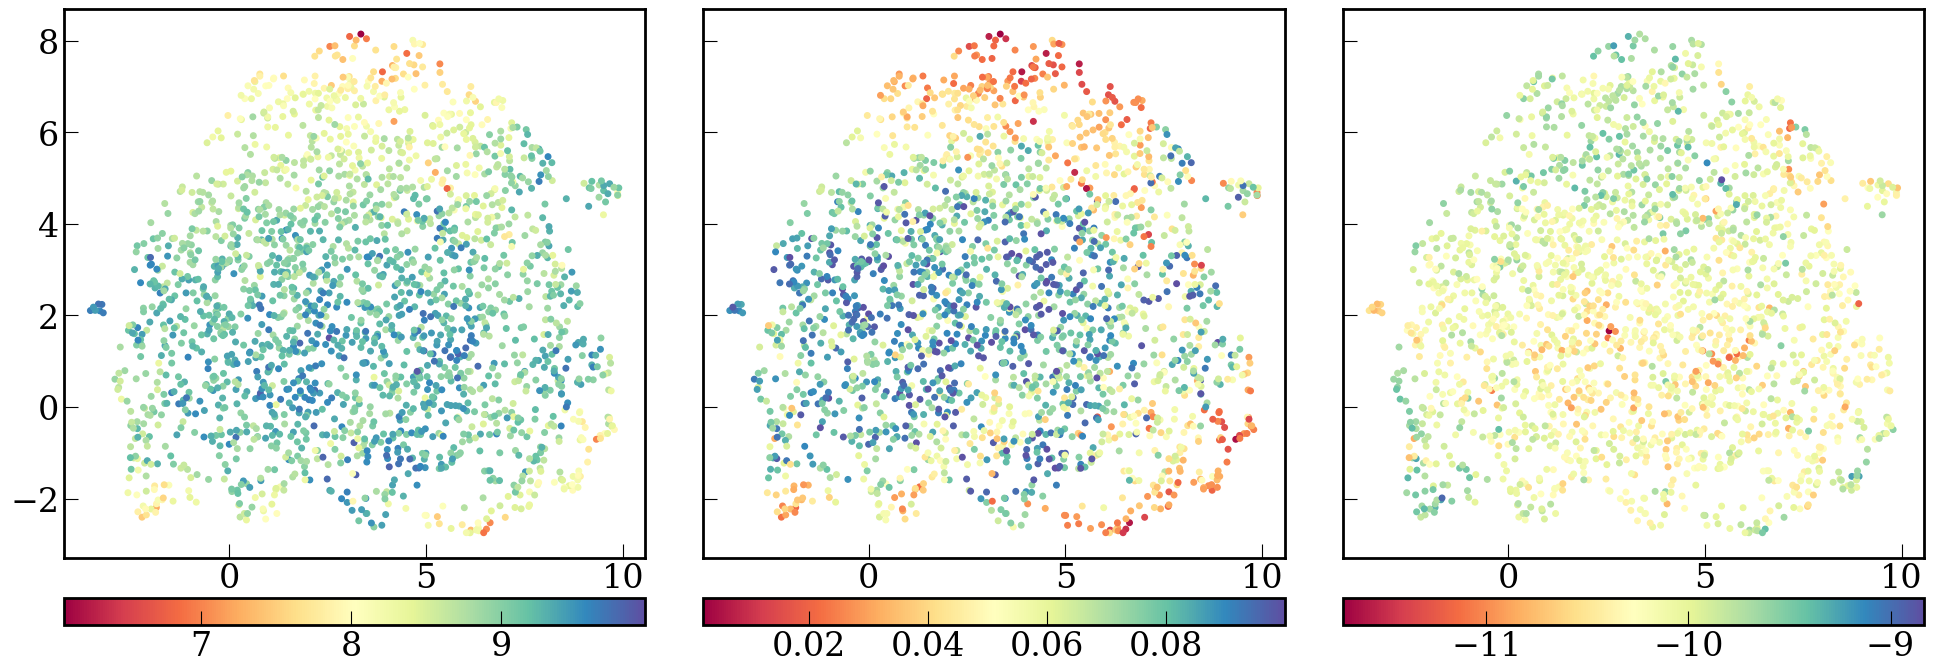

In [45]:
fig,ax=plt.subplots(1,3,figsize=(24,8),sharey='row',sharex='col')

target_key = ['logM','zspec','log_ssfr']
for j,ley in enumerate(target_key):
    im = ax[j].scatter(embedding[:,0],embedding[:,1],c=selc[target_key[j]],cmap=mcm.Spectral,s=16)
    ax[j].set_rasterized(True)

    divider = make_axes_locatable(ax[j])
    cax = divider.append_axes('bottom', size='5%', pad=0.4)
    fig.colorbar(im, cax=cax, orientation='horizontal')

plt.subplots_adjust(wspace=0.1)

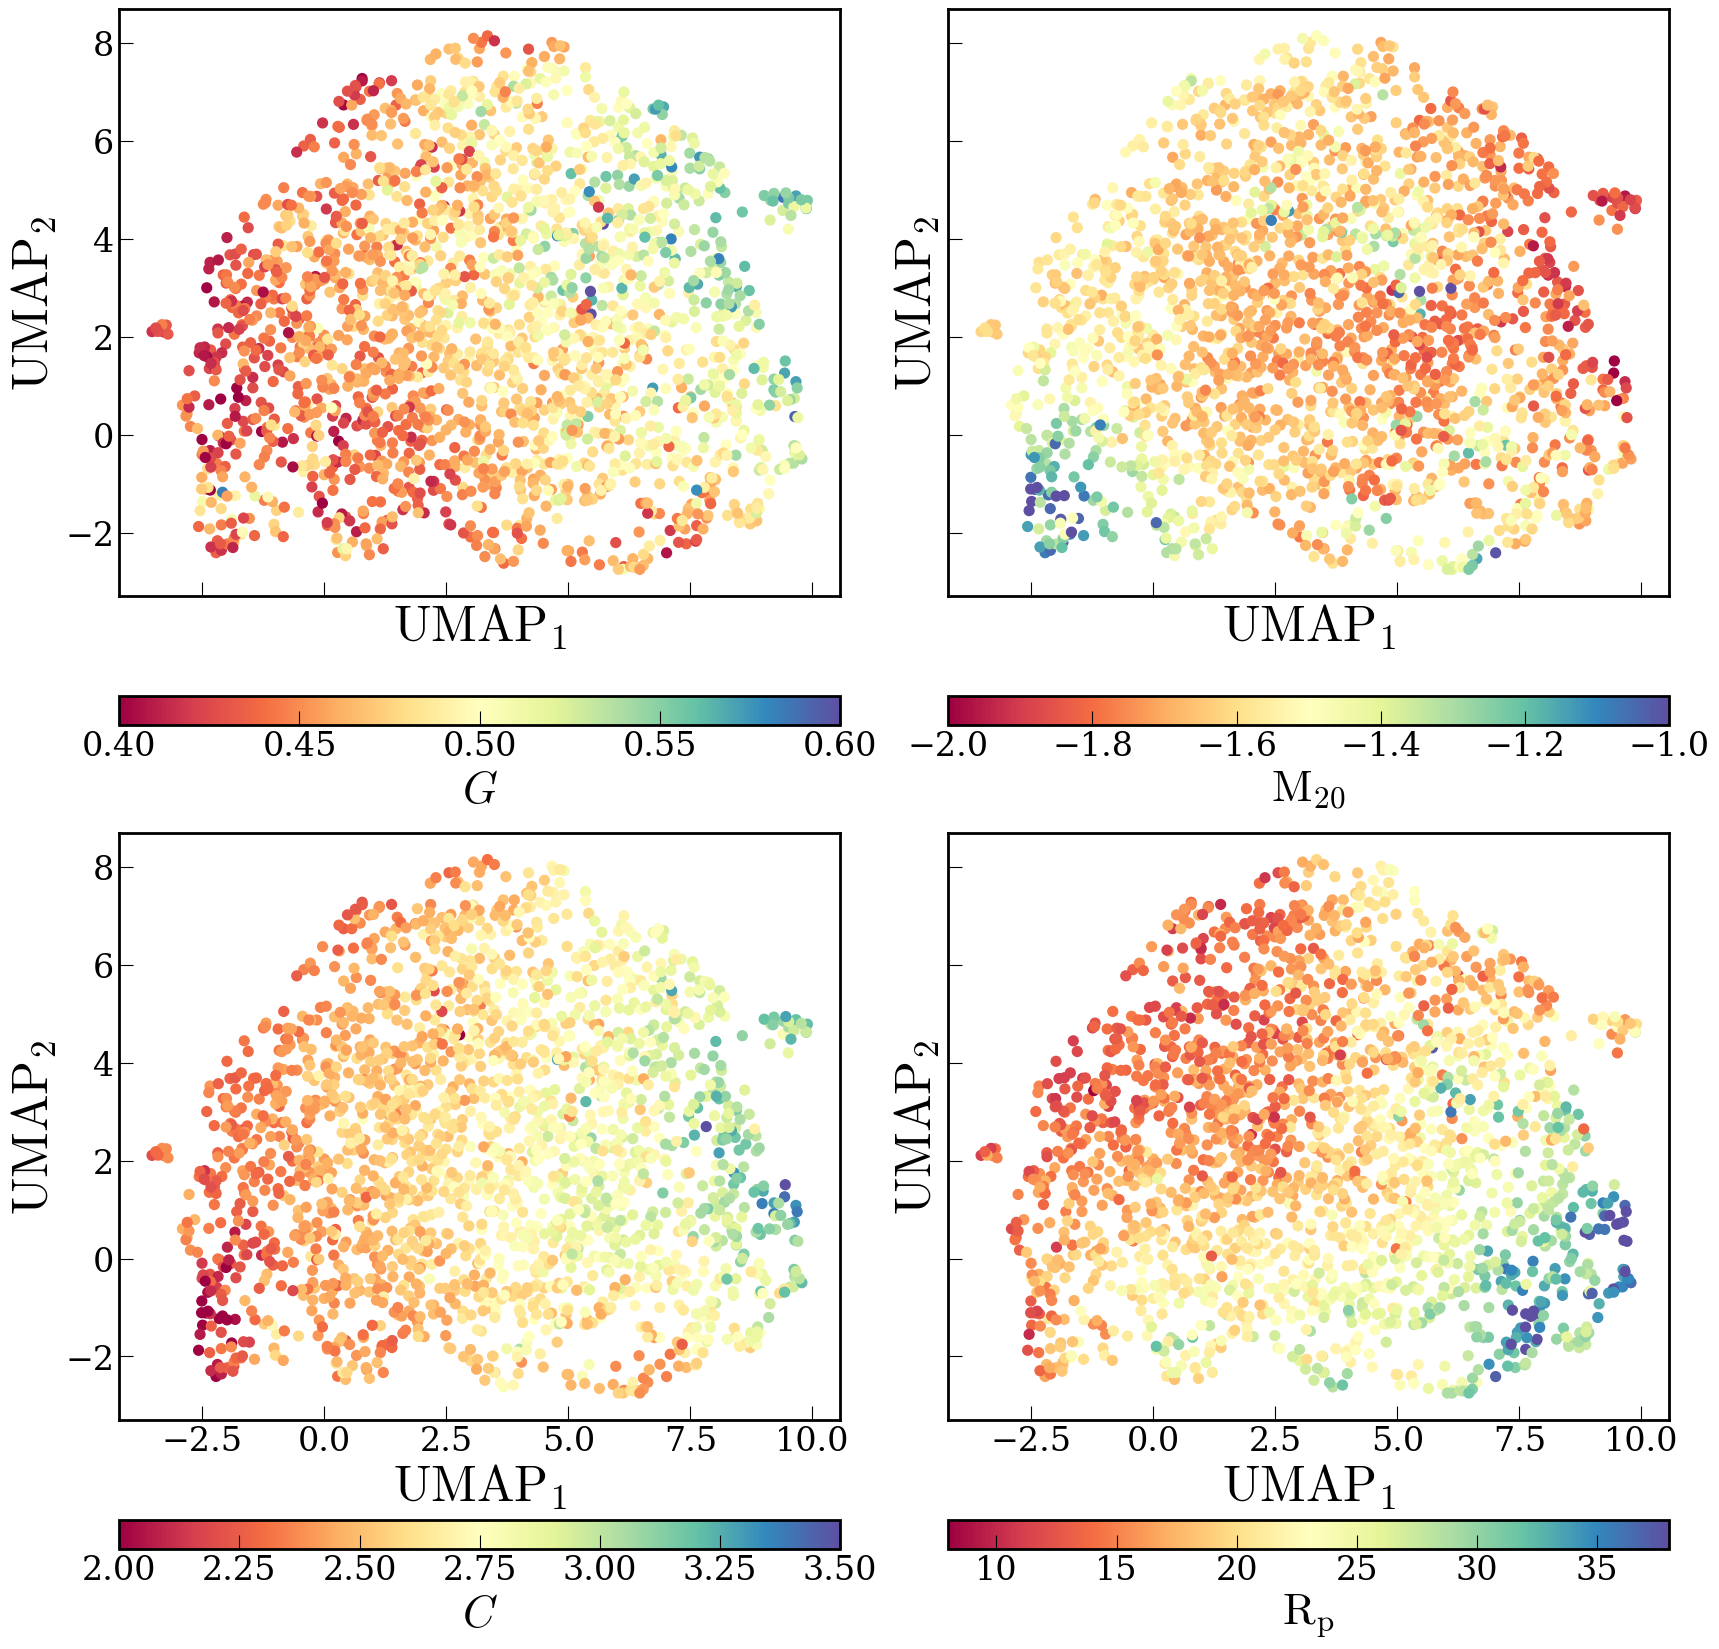

In [55]:
fig,ax=plt.subplots(2,2,figsize=(20,20),sharey='row',sharex='col')

key_list = list(npr.keys())
target_key = ['gini','m20','c','rpetro']
key_position = [key_list.index(t) for t in target_key]
    
for j,ley in enumerate(key_position):
    im = ax[j//2,j%2].scatter(embedding[:,0],embedding[:,1],c=selc[target_key[j]+'_r' ],cmap=mcm.Spectral,vmin=npr[key_list[ley]][0][0],vmax=npr[key_list[ley]][0][1],s=50)
    ax[j//2,j%2].set_rasterized(True)
    ax[j//2,j%2].set_xlabel(r'$UMAP_1$',fontsize=36)
    ax[j//2,j%2].set_ylabel(r'$UMAP_2$',fontsize=36)

    divider = make_axes_locatable(ax[j//2,j%2])
    cax = divider.append_axes('bottom', size='5%', pad=1.0)
    cbar = fig.colorbar(im, cax=cax, orientation='horizontal')
    cbar.set_label(label=npr[key_list[ley]][2],size=32)

plt.subplots_adjust(hspace=0.15,wspace=0.15)
plt.savefig('UMAP.pdf',bbox_inches='tight')